In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Loading the Dataset
data = pd.read_csv('netflix1.csv')

In [4]:
#Data Cleaning
#Check for missing values

print(data.isnull().sum())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [5]:
#Drop Duplicates if any
data.drop_duplicates(inplace=True)

In [6]:
data.head(5)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [7]:
# Drop rows with missing critical information
data.dropna(subset=['director',       'country'],
 inplace=True)
 

In [9]:
print(data.columns)

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')


In [10]:
# Convert 'date_added' to datetime
data['date_added'] = pd.to_datetime(data['date_added'])

In [11]:
data.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [12]:
# Show data types to confirm changes
print(data.dtypes)

show_id                 object
type                    object
title                   object
director                object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object


In [13]:
#Exploratory Data Analysis(EDA)

#Content type Distribution(Movies vs.TV Shows)
#Count the number of movie and TV shows

type_counts = data['type'].value_counts()
type_counts


type
Movie      6126
TV Show    2664
Name: count, dtype: int64

C:\Users\Amrita\AppData\Local\Temp\ipykernel_20200\1581522274.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x =type_counts.index, y= type_counts.values,palette = 'Set2')


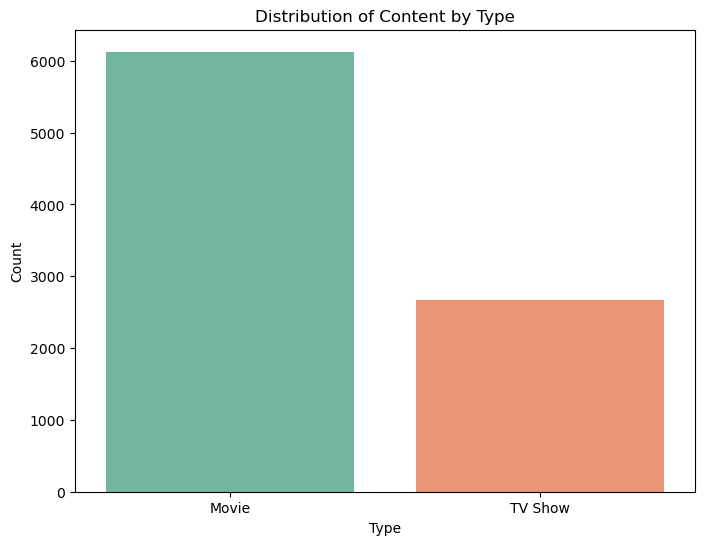

In [14]:
# # Plot the distribution

plt.figure(figsize=(8,6))
sns.barplot(x =type_counts.index, y= type_counts.values,palette = 'Set2')
plt.title('Distribution of Content by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [15]:
#Most Common Genre

#Lets split the 'listed_in' column and count generes

data['genres'] = data['listed_in'].apply(lambda x: x.split(','))
all_genres = sum(data['genres'],[])
genre_counts = pd.Series(all_genres).value_counts().head(10)

C:\Users\Amrita\AppData\Local\Temp\ipykernel_20200\1434657801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y= genre_counts.index,palette='Set3')


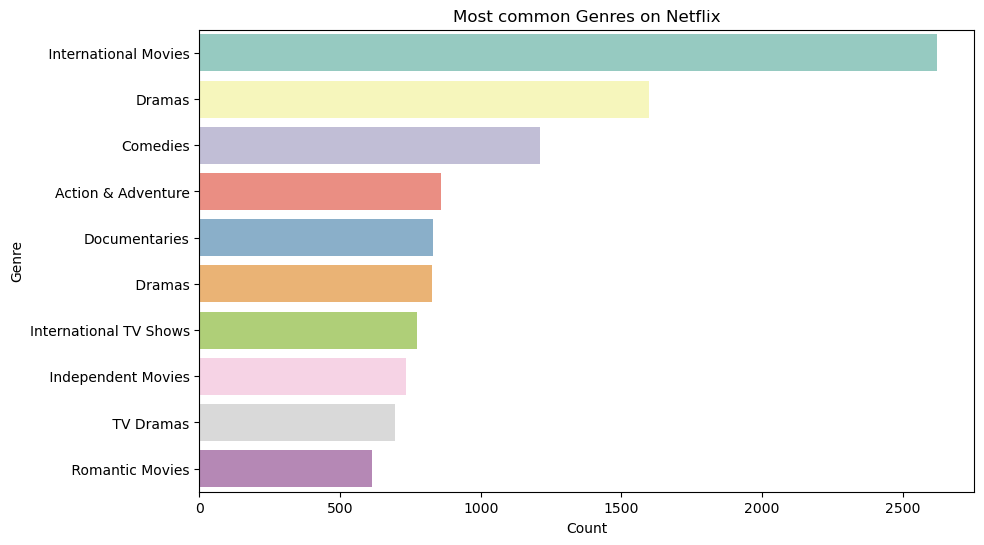

In [25]:
#Lets plot the common generes
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y= genre_counts.index,palette='Set3')
plt.title('Most common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

In [31]:
#Content Added Over Time

#Extracting year and month from 'date_added'

data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month

C:\Users\Amrita\AppData\Local\Temp\ipykernel_20200\3073417948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year_added',  data= data,palette='coolwarm')


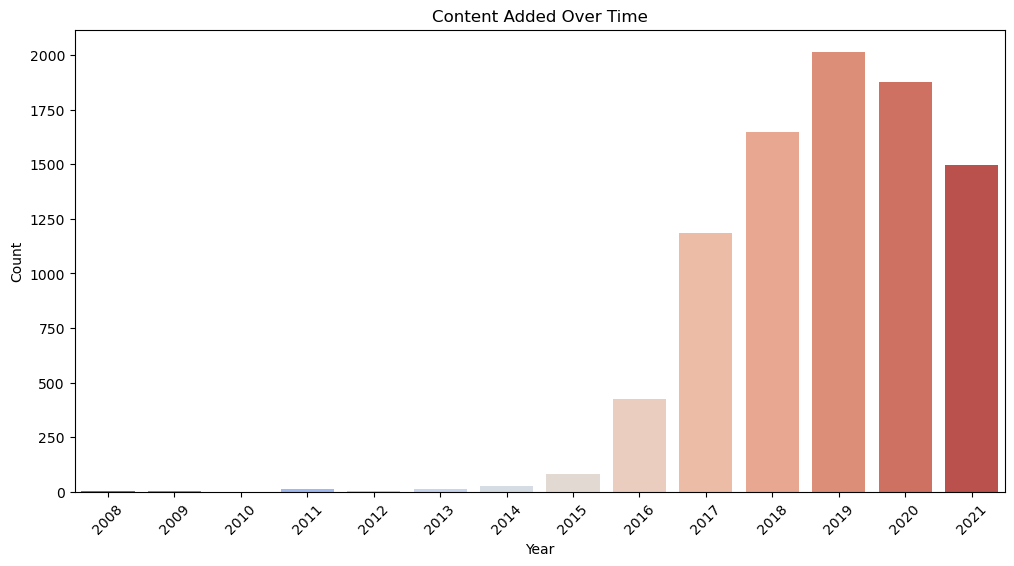

In [33]:
#Plot content added over the years
plt.figure(figsize=(12,6))
sns.countplot(x='year_added',  data= data,palette='coolwarm')
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [35]:
# Top 10 Directors with the Most Titles
#Count title by director

top_directors = data['director'].value_counts().head(10)
top_directors 

director
Not Given                 2588
Rajiv Chilaka               20
Alastair Fothergill         18
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Martin Scorsese             12
Youssef Chahine             12
Name: count, dtype: int64

C:\Users\Amrita\AppData\Local\Temp\ipykernel_20200\3557565138.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values,


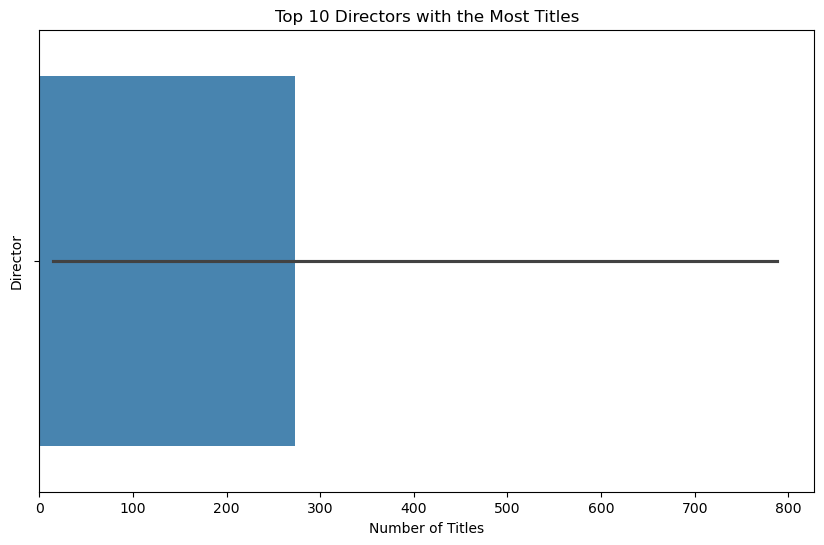

In [37]:
 # Plot top directors
 plt.figure(figsize=(10, 6))
 sns.barplot(x=top_directors.values,
 palette='Blues_d')
 y=top_directors.index,
 plt.title('Top 10 Directors with the Most Titles')
 plt.xlabel('Number of Titles')
 plt.ylabel('Director')
 plt.show()

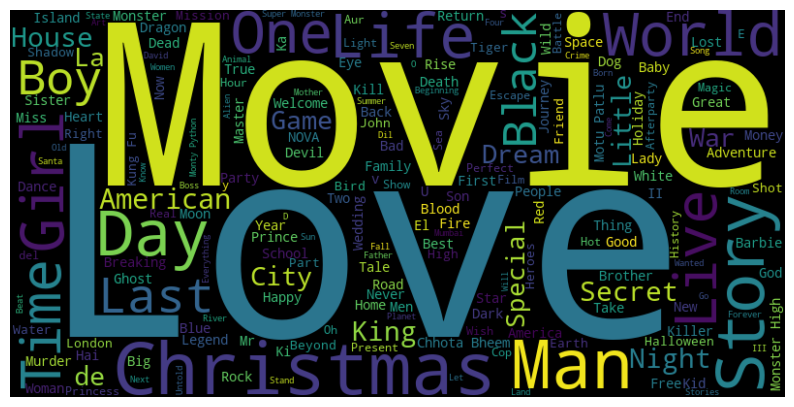

In [39]:
#World Cloud of Movie Titles
#Generate world cloud

movie_titles = data[data['type'] == 'Movie']['title']
text = ' '.join(movie_titles)  
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

#plot the cloud
plt.figure(figsize= (10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [40]:
#Feature Engineering


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
 10  genres        8790 non-null   object        
 11  year_added    8790 non-null   int32         
 12  month_added   8790 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(9)
memory usage: 824.2+ KB


In [45]:
#Content Distribution on Netflix

data['type'].value_counts()


type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [ ]:
#Visual representation of rating frequency of movies and TV Shows on Netflix.
#Which showing that movie content is more than the TV shows

Text(0.5, 0.98, 'TotalContentonNetflix')

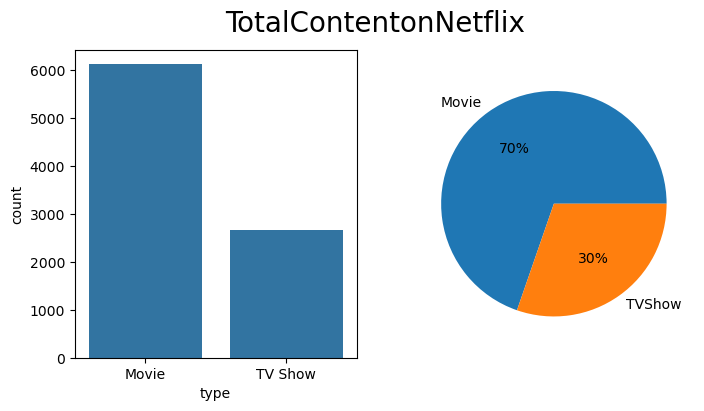

In [47]:
freq = data['type'].value_counts()
fig, axes=plt.subplots(1,2,  figsize= (8,4))
sns.countplot(data,x=data['type'],ax = axes[0])
plt.pie(freq,labels=['Movie','TVShow'],autopct='%.0f%%')
plt.suptitle('TotalContentonNetflix',fontsize=20)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
 10  genres        8790 non-null   object        
 11  year_added    8790 non-null   int32         
 12  month_added   8790 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(9)
memory usage: 824.2+ KB


In [51]:
data['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [57]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'genres',
       'year_added', 'month_added'],
      dtype='object')

In [79]:
ratings = data['rating'].value_counts().reset_index().sort_values(by='count',ascending=False)

NameError: name 'Text' is not defined

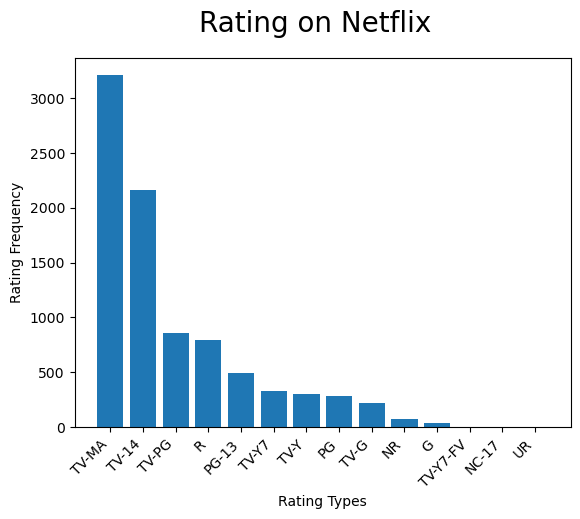

In [83]:
plt.bar(ratings['rating'],ratings['count'])
plt.xticks(rotation=45,ha= 'right')
plt.xlabel("Rating Types")
plt.ylabel("Rating Frequency")

plt.suptitle('Rating on Netflix',fontsize=20)



Text(0.5, 0.98, 'Rating on Netflix')

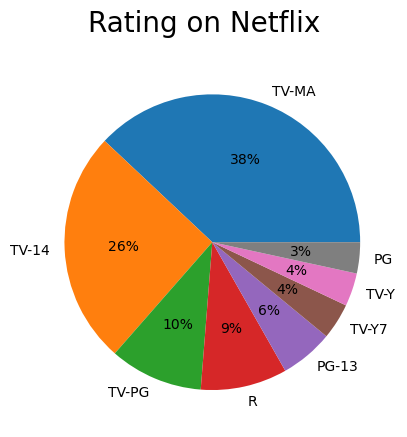

In [91]:
plt.pie(ratings['count'][:8], labels=ratings['rating'][:8],
autopct='%.0f%%')
plt.suptitle('Rating on Netflix', fontsize=20)


In [ ]:
#Lets find Top 10 countries with most content on Netflix

In [93]:
top_ten_countries = data['country'].value_counts().reset_index()
sort_values(by='count',ascending=False)[:10]

NameError: name 'sort_values' is not defined

In [95]:
top_ten_countries = data['country'].value_counts().reset_index()
top_ten_countries.columns = ['country', 'count']  # Renamed the  columns for clarity
top_ten_countries = top_ten_countries.sort_values(by='count', ascending=False).head(10)

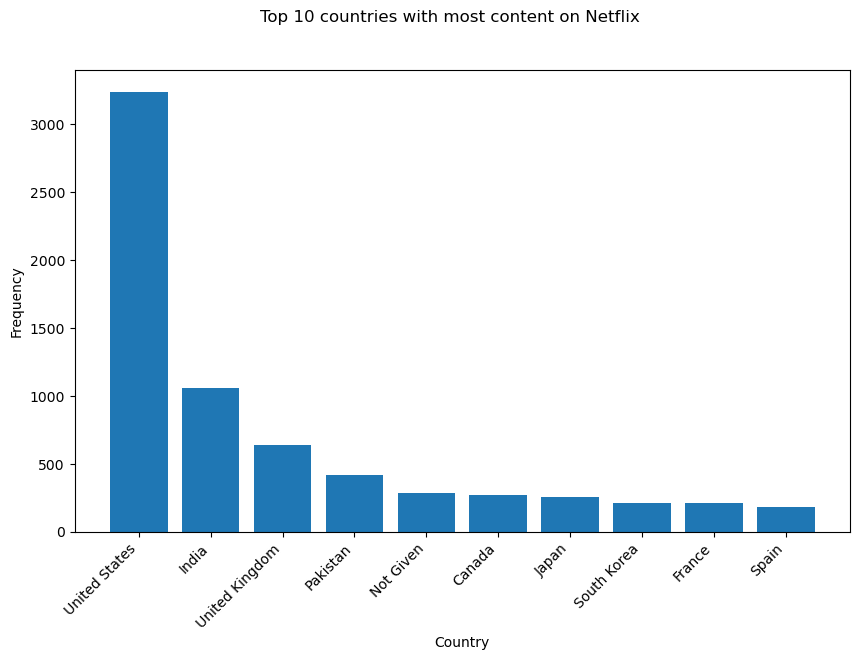

In [100]:
plt.figure(figsize=(10,6))
plt.bar(top_ten_countries['country'],
top_ten_countries['count'])
plt.xticks(rotation=45,ha='right')
plt.xlabel("Country")
plt.ylabel("Frequency")
plt.suptitle("Top 10 countries with most content on Netflix")
plt.show()


In [102]:
data['year']=data['date_added'].dt.year
data['month']=data['date_added'].dt.month
data['day']=data['date_added'].dt.day

In [ ]:
#Monthly releases of Movies and TV shows on Netflix

In [110]:
monthly_movie_release=data[data['type']=='Movie']['month'].value_counts().sort_index()
monthly_series_release=data[data['type']=='TV Show']['month'].value_counts().sort_index()

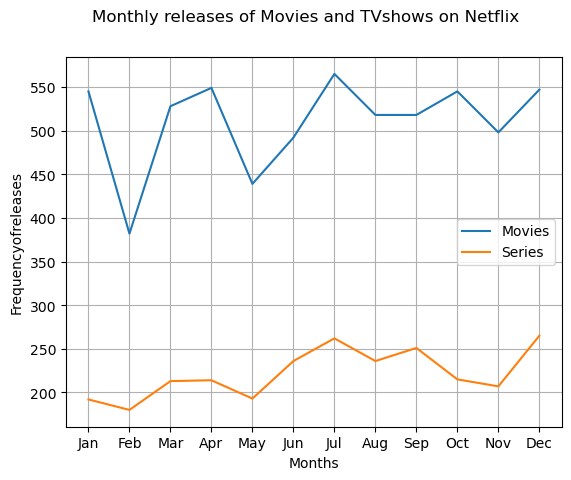

In [116]:
plt.plot(monthly_movie_release.index,
monthly_movie_release.values,label='Movies')
plt.plot(monthly_series_release.index,
monthly_series_release.values,label='Series')
plt.xlabel("Months")
plt.ylabel("Frequencyofreleases")
plt.xticks(range(1,13),['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(True)
plt.suptitle("Monthly releases of Movies and TVshows on Netflix")
plt.show()

In [120]:
#Yearly releases of Movies and TV Shows on Netflix

yearly_movie_releases=data[data['type']=='Movie']['year'].value_counts().sort_index()
yearly_series_releases=data[data['type']=='TV Show']['year'].value_counts().sort_index()

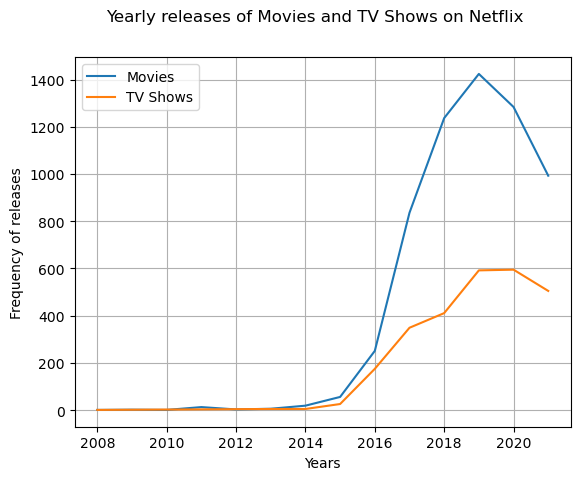

In [122]:
plt.plot(yearly_movie_releases.index,
yearly_movie_releases.values, label='Movies')
plt.plot(yearly_series_releases.index,
yearly_series_releases.values, label='TV Shows')
plt.xlabel("Years")
plt.ylabel("Frequency of releases")
plt.grid(True)
plt.suptitle("Yearly releases of Movies and TV Shows on Netflix")
plt.legend()


In [ ]:
# Top 10 popular movie genres

In [128]:
popular_movie_genre=data[data['type']=='Movie'].groupby("listed_in").size().sort_values(ascending=False)[:10]
popular_series_genre=data[data['type']=='TV show'].groupby("listed_in").size().sort_values(ascending=False)[:10]


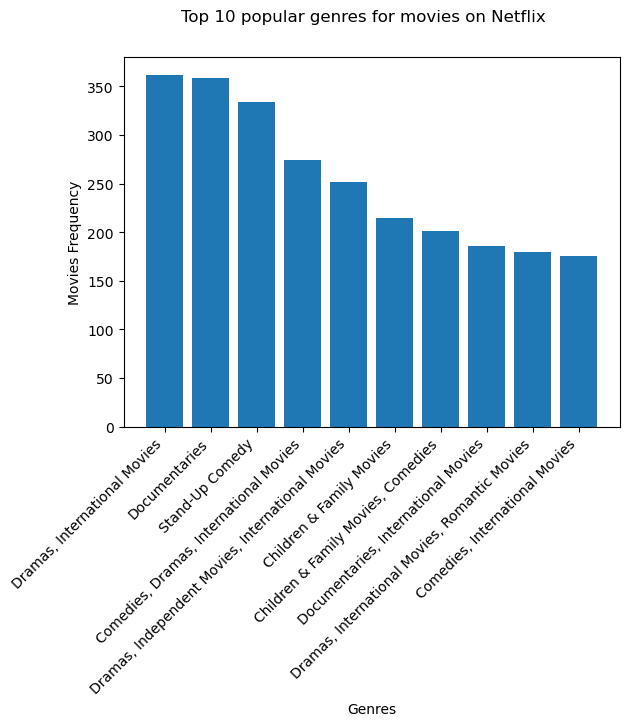

In [130]:
plt.bar(popular_movie_genre.index, popular_movie_genre.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Genres")
plt.ylabel("Movies Frequency")
plt.suptitle("Top 10 popular genres for movies on Netflix")
plt.show()

In [ ]:
#Top 10 TV Shows genres

In [136]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'genres',
       'year_added', 'month_added', 'year', 'month', 'day'],
      dtype='object')

In [149]:
# Top 10 genres for TV Shows
popular_series_genre = data[data['type'] == 'TV Show'].groupby("listed_in").size().sort_values(ascending=False)[:10]


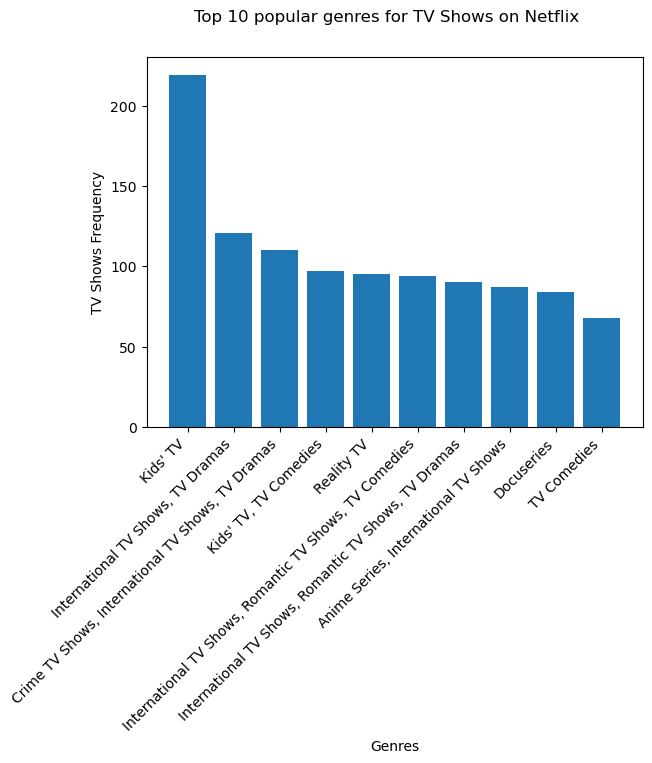

In [151]:
plt.bar(popular_series_genre.index,popular_series_genre.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Genres")
plt.ylabel("TV Shows Frequency")
plt.suptitle("Top 10 popular genres for TV Shows on Netflix")
plt.show()

In [ ]:
#Top 15 directors across Netflix with hoigh frequency of movies and shows.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Rajiv Chilaka'),
  Text(1, 0, 'Alastair Fothergill'),
  Text(2, 0, 'Raúl Campos, Jan Suter'),
  Text(3, 0, 'Suhas Kadav'),
  Text(4, 0, 'Marcus Raboy'),
  Text(5, 0, 'Jay Karas'),
  Text(6, 0, 'Cathy Garcia-Molina'),
  Text(7, 0, 'Youssef Chahine'),
  Text(8, 0, 'Jay Chapman'),
  Text(9, 0, 'Martin Scorsese'),
  Text(10, 0, 'Steven Spielberg'),
  Text(11, 0, 'Mark Thornton, Todd Kauffman'),
  Text(12, 0, 'Don Michael Paul'),
  Text(13, 0, 'David Dhawan')])

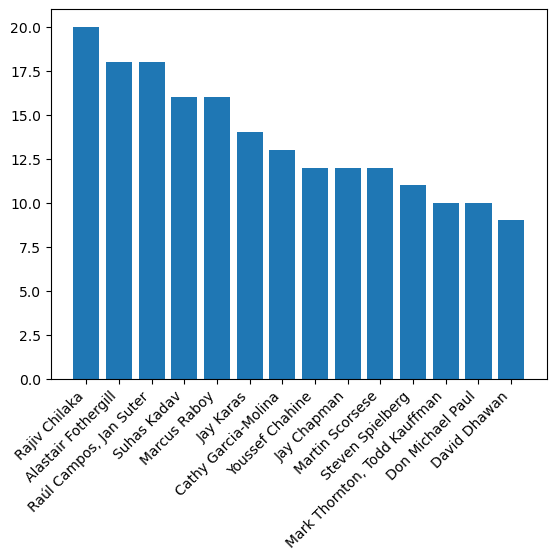

In [153]:
directors=data['director'].value_counts().reset_index().sort_values(by='count', ascending=False)[1:15]
plt.bar(directors['director'], directors['count'])
plt.xticks(rotation=45, ha='right')
